# Sales Prediction Model

A reproducible walkthrough. The outputs below are executed results from the pinned public dataset. See the README for full attribution and limitations.

## 1. Reproduce the pipeline

This invokes the same reusable code as the command line. Downloads are verified; cached data work offline.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "src").is_dir():
    raise RuntimeError("Open this notebook from the repository root or notebooks directory.")
sys.path.insert(0, str(ROOT))
from src.model import run
metrics = run()

{
  "observations": 200,
  "training_observations": 160,
  "test_observations": 40,
  "random_seed": 42,
  "test": {
    "r2": 0.899438024100912,
    "mae_thousands_of_units": 1.4607567168117606,
    "rmse_thousands_of_units": 1.7815996615334502
  },
  "mean_baseline_test": {
    "r2": -0.004757260886999015,
    "mae_thousands_of_units": 4.9625,
    "rmse_thousands_of_units": 5.631496248777939
  },
  "training_only_5fold_cv": {
    "r2_mean": 0.8702645398521053,
    "r2_std": 0.0803241548418059,
    "mae_mean": 1.237076238029796,
    "mae_std": 0.18246333827555045,
    "rmse_mean": 1.675809832290712,
    "rmse_std": 0.2974109461698416
  },
  "missing_values": 0,
  "duplicate_rows": 0,
  "target_units": "thousands of units; advertising inputs are thousands of dollars"
}


## 2. Inspect the evidence

The holdout has 40 rows; 160 training rows supply both the fitted model and cross-validation. The source row identifier is excluded from predictors.

In [2]:
pd.DataFrame({"Linear regression": metrics["test"], "Mean baseline": metrics["mean_baseline_test"]})

,Linear regression,Mean baseline
r2,0.899438,-0.004757
mae_thousands_of_units,1.460757,4.962500
rmse_thousands_of_units,1.781600,5.631496


In [3]:
pd.read_csv(ROOT / "reports/cross_validation.csv")

,fold,r2,mae,rmse
0,1,0.736607,1.551716,2.010699
1,2,0.853914,1.138354,1.989099
2,3,0.929143,1.126523,1.415850
3,4,0.921173,1.126712,1.464737
4,5,0.910487,1.242077,1.498664


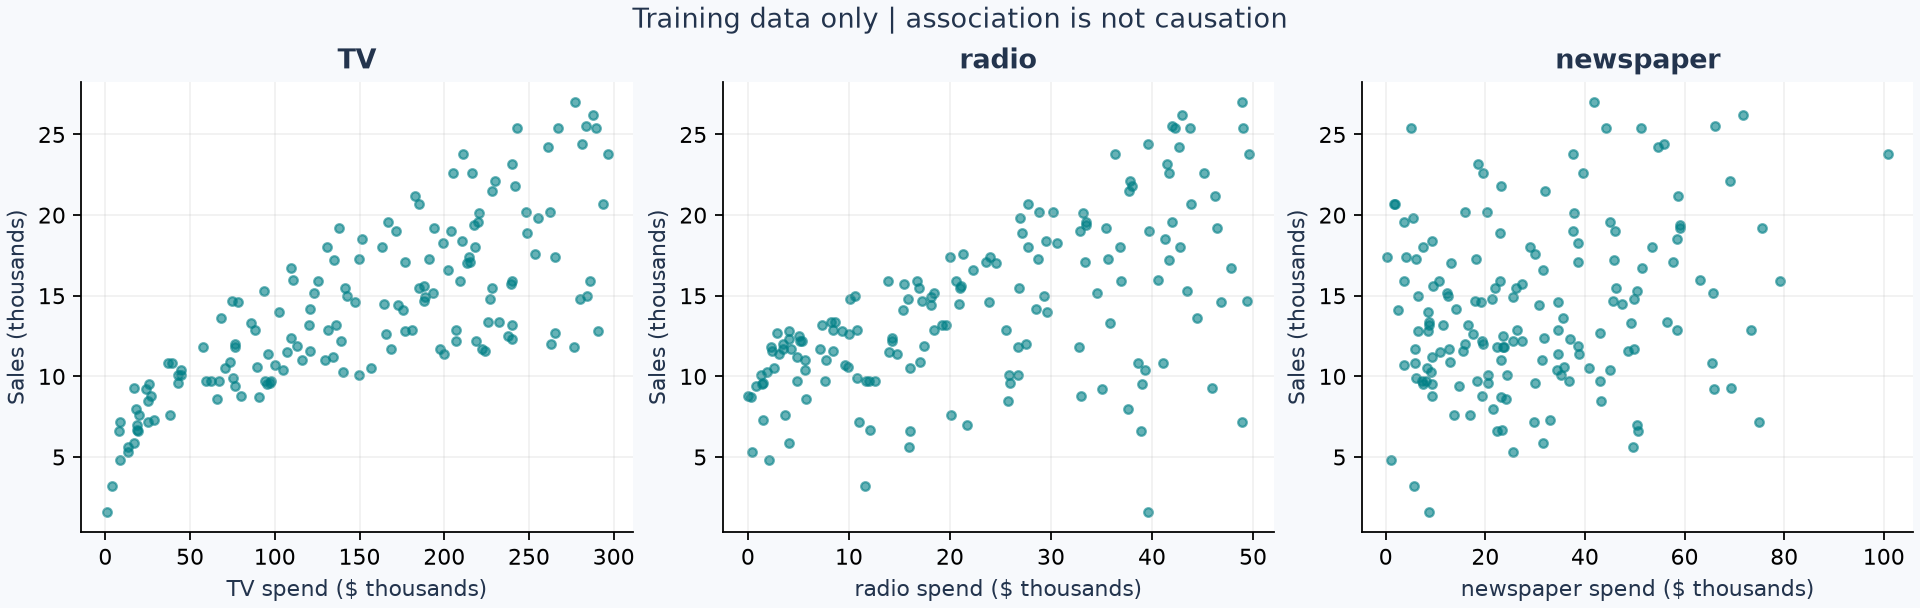

In [4]:
display(Image(filename=str(ROOT / "reports/training_relationships.png")))

In [5]:
pd.read_csv(ROOT / "reports/coefficients.csv")

,feature,coefficient
0,TV,0.044730
1,radio,0.189195
2,newspaper,0.002761


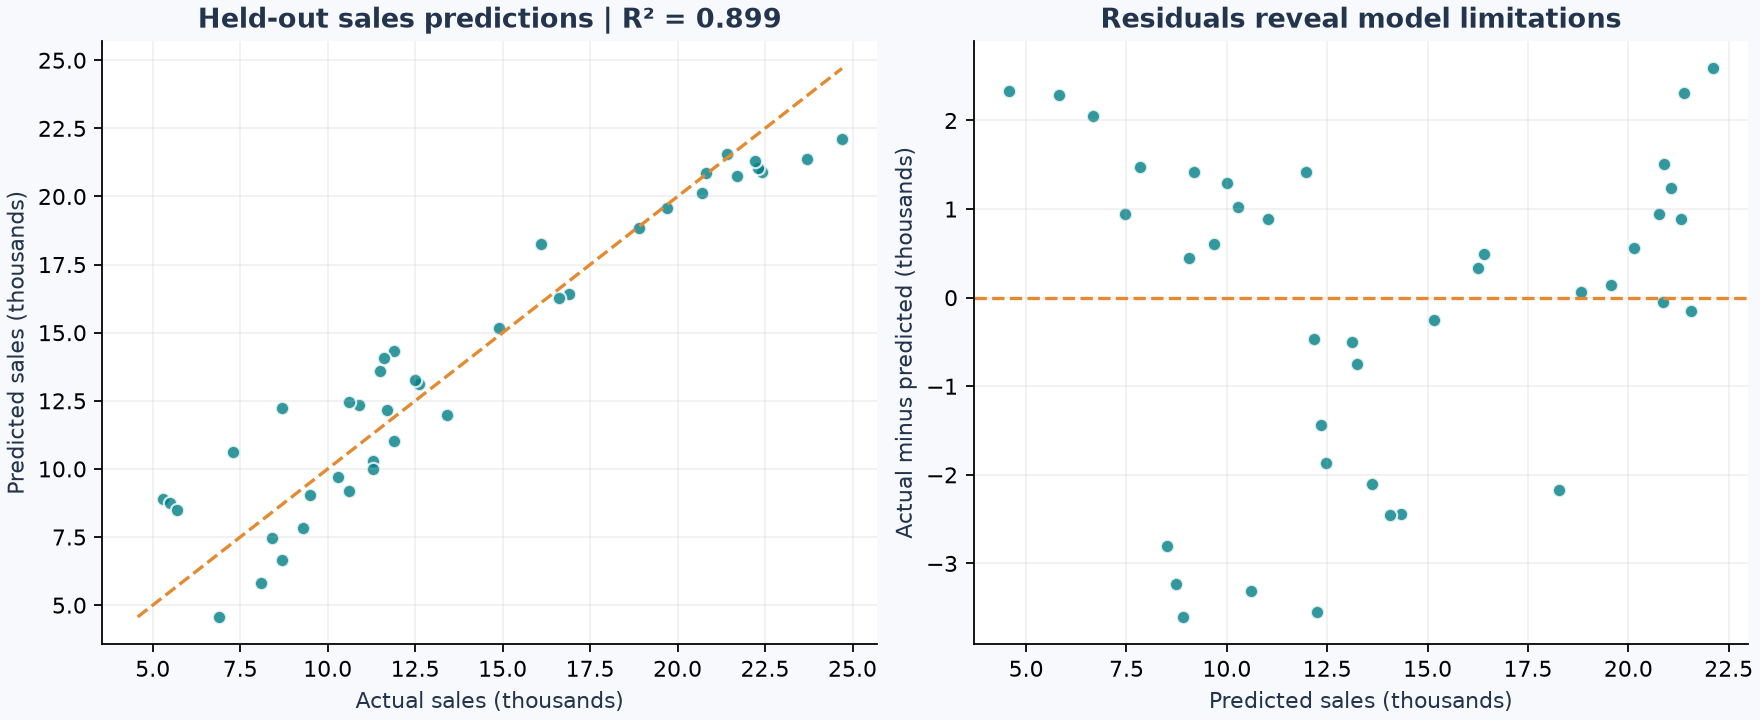

In [6]:
display(Image(filename=str(ROOT / "reports/model_evaluation.png")))

## 3. Inspect individual errors and make a prediction

In [7]:
predictions = pd.read_csv(ROOT / "reports/test_predictions.csv")
predictions.assign(absolute_error=predictions.residual.abs()).nlargest(5, "absolute_error")

,row_index,actual_sales,predicted_sales,residual,absolute_error
13,78,5.3,8.903493,-3.603493,3.603493
33,75,8.7,12.249664,-3.549664,3.549664
3,158,7.3,10.608503,-3.308503,3.308503
16,56,5.5,8.736284,-3.236284,3.236284
29,132,5.7,8.506699,-2.806699,2.806699


In [8]:
from src.model import predict
predict([100, 20, 10])

{'predicted_sales_thousands': 11.263531313095463,
 'outside_training_range': [],
 'note': 'Educational association model; predictions can be negative and are not causal budget advice.'}

## Interpretation

Held-out R² is 0.899; MAE is 1.461 thousand units. R² is not percentage accuracy. The model beats the mean baseline, but residual structure suggests missing nonlinear or interaction effects. Coefficients describe conditional associations, not causal advertising returns.

Next: investigate TV/radio interactions on training data and use a fresh holdout for further model selection.